# Exploring te_process.csv

This file holds readings from a simulated chemical plant: 52 gauges recorded over time, both while the plant runs normally and while it has one of 20 different breakdowns. We use Polars in lazy mode: the computer reads the 6 GB file in pieces instead of loading it all into memory at once (like reading a long book page by page instead of memorizing it).

<span style="font-family: Georgia, serif; font-style: italic;">Exploración de te_process.csv. Este archivo tiene lecturas de una planta química simulada: 52 medidores registrados en el tiempo, tanto con la planta funcionando normal como con una de 20 averías distintas. Usamos Polars en modo lazy: el computador lee el archivo de 6 GB por partes en vez de cargarlo completo en memoria (como leer un libro largo página por página en vez de memorizarlo entero).</span>

In [30]:
import os
import polars as pl
import numpy as np

CSV_PATH = os.path.join(os.getcwd(), "te_process.csv")
size = os.path.getsize(CSV_PATH)
print(f"{CSV_PATH} ({size / 1e9:.2f} GB, {size / 1024**3:.2f} GiB)")

/Users/esegard/Documents/Norrin/te_process.csv (6.01 GB, 5.60 GiB)


## First rows

A quick look at the first 5 rows. Each row is one moment in time: one reading from every gauge at once. The first columns say which scenario it is (`faultNumber`: 0 means no breakdown), which simulation it belongs to (`simulationRun`) and the time step (`sample`). Two things to keep in mind: `fault_status` labels the whole run (every row of a faulty run says `faulty`, even before the breakdown starts), and `faultNumber` / `fault_status` are for evaluation only, never for detection (see the last section).

<span style="font-family: Georgia, serif; font-style: italic;">Primeras filas. Un vistazo rápido a las primeras 5 filas. Cada fila es un instante: una lectura de todos los medidores a la vez. Las primeras columnas dicen de qué escenario es (faultNumber: 0 significa sin avería), a qué simulación pertenece (simulationRun) y el paso de tiempo (sample). Dos cosas para tener presentes: fault_status etiqueta la corrida completa (todas las filas de una corrida con avería dicen faulty, incluso antes de que empiece la avería), y faultNumber / fault_status son solo para evaluar, nunca para detectar (ver la última sección).</span>

In [16]:
preview = pl.read_csv(CSV_PATH, n_rows=5)
preview

faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,xmeas_11,xmeas_12,xmeas_13,xmeas_14,xmeas_15,xmeas_16,xmeas_17,xmeas_18,xmeas_19,xmeas_20,xmeas_21,xmeas_22,xmeas_23,xmeas_24,xmeas_25,xmeas_26,xmeas_27,xmeas_28,xmeas_29,xmeas_30,xmeas_31,xmeas_32,xmeas_33,xmeas_34,xmeas_35,xmeas_36,xmeas_37,xmeas_38,xmeas_39,xmeas_40,xmeas_41,xmv_1,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,source,fault_status
f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
0.0,1.0,1,0.25038,3674.0,4529.0,9.232,26.889,42.402,2704.3,74.863,120.41,0.33818,80.044,51.435,2632.9,25.029,50.528,3101.1,22.819,65.732,229.61,341.22,94.64,77.047,32.188,8.8933,26.383,6.882,18.776,1.6567,32.958,13.823,23.978,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828,62.881,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.51,41.258,18.447,"""train""","""normal"""
0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,75.0,120.41,0.3362,80.078,50.154,2633.8,24.419,48.772,3102.0,23.333,65.716,230.54,341.3,94.595,77.434,32.188,8.8933,26.383,6.882,18.776,1.6567,32.958,13.823,23.978,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828,63.132,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,"""train""","""normal"""
0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.07,2706.2,74.771,120.42,0.33563,80.22,50.302,2635.5,25.244,50.071,3103.5,21.924,65.732,230.08,341.38,94.605,77.466,31.767,8.7694,26.095,6.8259,18.961,1.6292,32.985,13.742,23.897,1.3001,18.765,2.2602,4.8543,2.39,0.017866,0.8357,0.098577,53.724,43.828,63.117,54.357,24.666,61.275,22.38,40.244,38.99,46.699,47.468,41.199,20.53,"""train""","""normal"""
0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,75.224,120.39,0.33553,80.305,49.99,2635.6,23.268,50.435,3102.8,22.948,65.781,227.91,341.71,94.473,77.443,31.767,8.7694,26.095,6.8259,18.961,1.6292,32.985,13.742,23.897,1.3001,18.765,2.2602,4.8543,2.39,0.017866,0.8357,0.098577,53.724,43.828,63.1,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089,"""train""","""normal"""
0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.65,2705.1,75.388,120.39,0.32632,80.064,51.31,2632.4,26.099,50.48,3103.5,22.808,65.788,231.37,341.11,94.678,76.947,32.322,8.5821,26.769,6.8688,18.782,1.6396,33.071,13.834,24.228,1.0938,18.666,2.2193,4.8304,2.2416,0.017866,0.8357,0.098577,53.724,43.828,63.313,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461,"""train""","""normal"""


## Schema (columns and types)

The list of all 57 columns and the kind of value each one holds. Almost all are decimal numbers (`Float64`); `source` and `fault_status` are text labels (train or test, normal or faulty).

<span style="font-family: Georgia, serif; font-style: italic;">Esquema (columnas y tipos). La lista de las 57 columnas y el tipo de valor de cada una. Casi todas son números decimales (Float64); source y fault_status son etiquetas de texto (train o test, normal o con falla).</span>

In [17]:
lf = pl.scan_csv(CSV_PATH)
pl.DataFrame({"columna": list(lf.collect_schema().keys()), "tipo": [str(t) for t in lf.collect_schema().values()]})

columna,tipo
str,str
"""faultNumber""","""Float64"""
"""simulationRun""","""Float64"""
"""sample""","""Int64"""
"""xmeas_1""","""Float64"""
"""xmeas_2""","""Float64"""
…,…
"""xmv_9""","""Float64"""
"""xmv_10""","""Float64"""
"""xmv_11""","""Float64"""


## Number of rows

How big the table is: 15.33 million rows. That is why we avoid loading everything at once.

<span style="font-family: Georgia, serif; font-style: italic;">Número de filas. Qué tan grande es la tabla: 15,33 millones de filas. Por eso evitamos cargar todo de una vez.</span>

In [18]:
lf.select(pl.len().alias("filas")).collect()

filas
u32
15330000


## Rows per fault type, source and status

How many rows exist for each scenario: normal operation, or breakdown number 1 to 20. Each is split into `train` (data used to teach a model) and `test` (data kept aside to check the model). Within each source every scenario has the same number of rows (train: 500 runs x 500 samples = 250,000; test: 500 runs x 960 samples = 480,000), so none is over-represented.

<span style="font-family: Georgia, serif; font-style: italic;">Filas por tipo de falla, origen y estado. Cuántas filas hay de cada escenario: operación normal o avería número 1 a 20. Cada uno se divide en train (datos para enseñarle a un modelo) y test (datos guardados aparte para comprobarlo). Dentro de cada origen todos los escenarios tienen la misma cantidad de filas (train: 500 corridas x 500 muestras = 250.000; test: 500 corridas x 960 muestras = 480.000), así que ninguno pesa más que otro.</span>

In [19]:
(
    lf.group_by(["faultNumber", "source", "fault_status"])
    .agg(pl.len().alias("filas"))
    .sort(["source", "faultNumber"])
    .collect()
)

faultNumber,source,fault_status,filas
f64,str,str,u32
0.0,"""test""","""normal""",480000
1.0,"""test""","""faulty""",480000
2.0,"""test""","""faulty""",480000
3.0,"""test""","""faulty""",480000
4.0,"""test""","""faulty""",480000
…,…,…,…
16.0,"""train""","""faulty""",250000
17.0,"""train""","""faulty""",250000
18.0,"""train""","""faulty""",250000


## Statistics of the xmeas / xmv variables

A health check of every gauge: the average (`mean`), how much values typically move around that average (`std`), the lowest and highest value ever seen, and how many readings are missing (`nulls`). Here nothing is missing and the ranges look plausible.

<span style="font-family: Georgia, serif; font-style: italic;">Estadísticas de las variables xmeas / xmv. Un chequeo de salud de cada medidor: el promedio (mean), cuánto se mueven normalmente los valores alrededor de ese promedio (std), el valor más bajo y más alto que se ha visto, y cuántas lecturas faltan (nulls). Aquí no falta nada y los rangos se ven razonables.</span>

In [20]:
cols = [c for c in lf.collect_schema().names() if c.startswith(("xmeas_", "xmv_"))]
stats = lf.select(
    [pl.col(c).mean().alias(f"{c}|mean") for c in cols]
    + [pl.col(c).std().alias(f"{c}|std") for c in cols]
    + [pl.col(c).min().alias(f"{c}|min") for c in cols]
    + [pl.col(c).max().alias(f"{c}|max") for c in cols]
    + [pl.col(c).null_count().alias(f"{c}|nulls") for c in cols]
).collect().row(0)
names = [f"{c}|{s}" for s in ("mean", "std", "min", "max", "nulls") for c in cols]
lookup = dict(zip(names, stats))
stats_df = pl.DataFrame({
    "variable": cols,
    **{s: [lookup[f"{c}|{s}"] for c in cols] for s in ("mean", "std", "min", "max", "nulls")},
})
stats_df

variable,mean,std,min,max,nulls
str,f64,f64,f64,f64,i64
"""xmeas_1""",0.257832,0.140945,-0.004986,1.0175,0
"""xmeas_2""",3664.629989,42.908283,3308.4,3906.7,0
"""xmeas_3""",4508.765881,107.005866,3540.7,5175.8,0
"""xmeas_4""",9.381278,0.367158,6.6399,12.24,0
"""xmeas_5""",26.901456,0.228236,25.348,28.565,0
…,…,…,…,…,…
"""xmv_7""",38.057386,2.942525,22.288,54.23,0
"""xmv_8""",46.432792,2.347796,33.369,60.216,0
"""xmv_9""",49.876491,17.144151,-0.68342,100.58,0


## Example: one full simulation (normal, run 1)

The plot shows how a few gauges move over time in one normal run. Small wiggles are expected: even a healthy plant is never perfectly still. This is the picture of "normal" that we later compare breakdowns against.

<span style="font-family: Georgia, serif; font-style: italic;">Ejemplo: una simulación completa (normal, run 1). El gráfico muestra cómo se mueven algunos medidores en el tiempo en una corrida normal. Los pequeños vaivenes son esperables: incluso una planta sana nunca está perfectamente quieta. Esta es la imagen de "normal" contra la que después comparamos las averías.</span>

(500, 57)


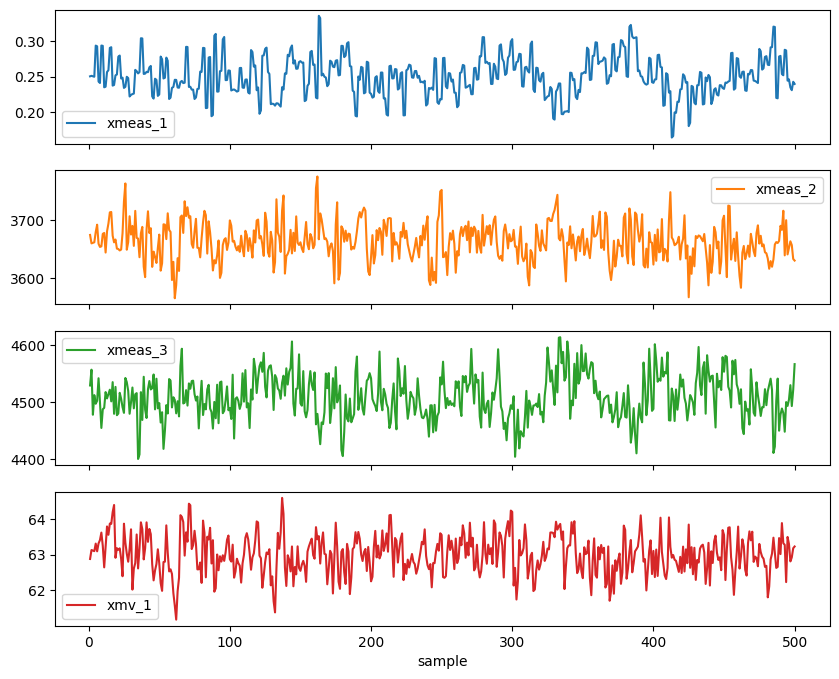

In [21]:
run = (
    lf.filter((pl.col("faultNumber") == 0) & (pl.col("simulationRun") == 1) & (pl.col("source") == "train"))
    .collect()
)
print(run.shape)
run.select(["sample", "xmeas_1", "xmeas_2", "xmeas_3", "xmv_1"]).to_pandas().set_index("sample").plot(subplots=True, figsize=(10, 8));

## Sensor dictionary

This looks like the Tennessee Eastman Process (TEP): a well-known made-up chemical plant that researchers use to test breakdown-detection methods. Nothing is real, but it behaves like a real plant. In simple terms: raw ingredients go into a reactor, the product is separated and purified, and the unused gas is sent back to try again.

The 52 variables fall in three groups:

- **xmeas_1 to xmeas_22, the dashboard gauges.** Like the dials in a car: how much liquid or gas is flowing, pressure, how full a tank is (level), temperatures, and how hard the compressor works.
- **xmeas_23 to xmeas_41, the lab analyzers.** Every few minutes a small sample of gas or product is analyzed and the result says what it is made of, as a percentage of each component (mol%). Think of a lab test rather than a live gauge.
- **xmv_1 to xmv_11, the pedals and taps.** Valve positions from 0% (closed) to 100% (fully open). The automatic control system moves them all the time to keep the plant steady, a bit like cruise control moving the accelerator.

`faultNumber` 0 is normal operation, 1 to 20 are the breakdown types (a valve sticks, a feed changes, cooling water gets warmer, and so on). `simulationRun` identifies each independent simulation and `sample` is the time step, one every 3 minutes.

The names and units in the table below are the public Tennessee Eastman descriptions, so they are hypotheses, not facts read from the data. The last section checks some of them against the data.

<span style="font-family: Georgia, serif; font-style: italic;">Diccionario de sensores. Parece ser el Tennessee Eastman Process (TEP): una planta química inventada, muy conocida, que los investigadores usan para probar métodos de detección de averías. Nada es real, pero se comporta como una planta real. En simple: entran ingredientes a un reactor, el producto se separa y se purifica, y el gas que no se usó se devuelve para intentarlo de nuevo. Las 52 variables son de tres grupos. xmeas_1 a xmeas_22, los medidores del tablero: como los relojes de un auto, cuánto líquido o gas circula, presión, qué tan lleno está un estanque (nivel), temperaturas y cuánto trabaja el compresor. xmeas_23 a xmeas_41, los analizadores de laboratorio: cada cierto tiempo se analiza una muestra pequeña y el resultado dice de qué está hecha, como porcentaje de cada componente (mol%); es más parecido a un examen de laboratorio que a un medidor en vivo. xmv_1 a xmv_11, los pedales y llaves: posición de las válvulas de 0% (cerrada) a 100% (totalmente abierta); el sistema de control automático las mueve todo el tiempo para mantener la planta estable, un poco como el control de crucero mueve el acelerador. faultNumber 0 es operación normal, 1 a 20 son los tipos de avería (se pega una válvula, cambia una alimentación, el agua de enfriamiento se calienta, etc.). simulationRun identifica cada simulación independiente y sample es el paso de tiempo, uno cada 3 minutos. Los nombres y unidades de la tabla de abajo son las descripciones públicas del Tennessee Eastman, así que son hipótesis, no hechos leídos de los datos. La última sección contrasta algunas con los datos.</span>

In [22]:
rows = [
    ("xmeas_1", "A feed (stream 1)", "kscmh"),
    ("xmeas_2", "D feed (stream 2)", "kg/h"),
    ("xmeas_3", "E feed (stream 3)", "kg/h"),
    ("xmeas_4", "A and C feed (stream 4)", "kscmh"),
    ("xmeas_5", "Recycle flow (stream 8)", "kscmh"),
    ("xmeas_6", "Reactor feed rate (stream 6)", "kscmh"),
    ("xmeas_7", "Reactor pressure", "kPa gauge"),
    ("xmeas_8", "Reactor level", "%"),
    ("xmeas_9", "Reactor temperature", "°C"),
    ("xmeas_10", "Purge rate (stream 9)", "kscmh"),
    ("xmeas_11", "Product separator temperature", "°C"),
    ("xmeas_12", "Product separator level", "%"),
    ("xmeas_13", "Product separator pressure", "kPa gauge"),
    ("xmeas_14", "Product separator underflow (stream 10)", "m3/h"),
    ("xmeas_15", "Stripper level", "%"),
    ("xmeas_16", "Stripper pressure", "kPa gauge"),
    ("xmeas_17", "Stripper underflow (stream 11)", "m3/h"),
    ("xmeas_18", "Stripper temperature", "°C"),
    ("xmeas_19", "Stripper steam flow", "kg/h"),
    ("xmeas_20", "Compressor work", "kW"),
    ("xmeas_21", "Reactor cooling water outlet temperature", "°C"),
    ("xmeas_22", "Separator cooling water outlet temperature", "°C"),
]
rows += [(f"xmeas_{23 + i}", f"Reactor feed analysis, component {k}", "mol%") for i, k in enumerate("ABCDEF")]
rows += [(f"xmeas_{29 + i}", f"Purge gas analysis, component {k}", "mol%") for i, k in enumerate("ABCDEFGH")]
rows += [(f"xmeas_{37 + i}", f"Product analysis, component {k}", "mol%") for i, k in enumerate("DEFGH")]
rows += [
    ("xmv_1", "D feed flow valve (stream 2)", "%"),
    ("xmv_2", "E feed flow valve (stream 3)", "%"),
    ("xmv_3", "A feed flow valve (stream 1)", "%"),
    ("xmv_4", "A and C feed flow valve (stream 4)", "%"),
    ("xmv_5", "Compressor recycle valve", "%"),
    ("xmv_6", "Purge valve (stream 9)", "%"),
    ("xmv_7", "Separator liquid flow valve (stream 10)", "%"),
    ("xmv_8", "Stripper liquid product flow valve (stream 11)", "%"),
    ("xmv_9", "Stripper steam valve", "%"),
    ("xmv_10", "Reactor cooling water valve", "%"),
    ("xmv_11", "Condenser cooling water valve", "%"),
]
sensor_info = pl.DataFrame(rows, schema=["variable", "description", "unit"], orient="row").with_columns(
    pl.when(pl.col("variable").str.starts_with("xmv_")).then(pl.lit("manipulated variable"))
    .when(pl.col("variable").str.extract(r"(\d+)").cast(pl.Int32) <= 22).then(pl.lit("process measurement"))
    .otherwise(pl.lit("composition analyzer"))
    .alias("group")
)
with pl.Config(tbl_rows=60, fmt_str_lengths=60):
    display(sensor_info)

variable,description,unit,group
str,str,str,str
"""xmeas_1""","""A feed (stream 1)""","""kscmh""","""process measurement"""
"""xmeas_2""","""D feed (stream 2)""","""kg/h""","""process measurement"""
"""xmeas_3""","""E feed (stream 3)""","""kg/h""","""process measurement"""
"""xmeas_4""","""A and C feed (stream 4)""","""kscmh""","""process measurement"""
"""xmeas_5""","""Recycle flow (stream 8)""","""kscmh""","""process measurement"""
"""xmeas_6""","""Reactor feed rate (stream 6)""","""kscmh""","""process measurement"""
"""xmeas_7""","""Reactor pressure""","""kPa gauge""","""process measurement"""
"""xmeas_8""","""Reactor level""","""%""","""process measurement"""
"""xmeas_9""","""Reactor temperature""","""°C""","""process measurement"""


## Statistics with sensor meaning

The same statistics as above, now with the name and unit of each gauge, so you can judge whether a number makes sense. For example, a valve is measured in % and should stay roughly between 0 and 100.

<span style="font-family: Georgia, serif; font-style: italic;">Estadísticas con el significado del sensor. Las mismas estadísticas de arriba, ahora con el nombre y la unidad de cada medidor, para poder juzgar si un número tiene sentido. Por ejemplo, una válvula se mide en % y debería estar más o menos entre 0 y 100.</span>

In [23]:
stats_df.join(sensor_info, on="variable").select(
    ["variable", "group", "description", "unit", "mean", "std", "min", "max"]
)

variable,group,description,unit,mean,std,min,max
str,str,str,str,f64,f64,f64,f64
"""xmeas_1""","""process measurement""","""A feed (stream 1)""","""kscmh""",0.257832,0.140945,-0.004986,1.0175
"""xmeas_2""","""process measurement""","""D feed (stream 2)""","""kg/h""",3664.629989,42.908283,3308.4,3906.7
"""xmeas_3""","""process measurement""","""E feed (stream 3)""","""kg/h""",4508.765881,107.005866,3540.7,5175.8
"""xmeas_4""","""process measurement""","""A and C feed (stream 4)""","""kscmh""",9.381278,0.367158,6.6399,12.24
"""xmeas_5""","""process measurement""","""Recycle flow (stream 8)""","""kscmh""",26.901456,0.228236,25.348,28.565
…,…,…,…,…,…,…,…
"""xmv_7""","""manipulated variable""","""Separator liquid flow valve (s…","""%""",38.057386,2.942525,22.288,54.23
"""xmv_8""","""manipulated variable""","""Stripper liquid product flow v…","""%""",46.432792,2.347796,33.369,60.216
"""xmv_9""","""manipulated variable""","""Stripper steam valve""","""%""",49.876491,17.144151,-0.68342,100.58


## Sampling rate per sensor

Most gauges update every 3 minutes, but the lab analyzers (xmeas_23 to xmeas_41) only report every 6 or 15 minutes. Between reports the last value is simply repeated, like a weather app that refreshes once an hour. The table shows the % of rows where the value really changes in one normal run; anything under 90% is one of the slow ones.

<span style="font-family: Georgia, serif; font-style: italic;">Frecuencia de muestreo por sensor. La mayoría de los medidores se actualiza cada 3 minutos, pero los analizadores de laboratorio (xmeas_23 a xmeas_41) solo informan cada 6 o 15 minutos. Entre un informe y otro se repite el último valor, como una app del clima que se refresca una vez por hora. La tabla muestra el % de filas en que el valor realmente cambia en una corrida normal; todo lo que esté bajo 90% es de los lentos.</span>

In [24]:
change_rate = run.select(
    [(pl.col(c).diff().fill_null(0) != 0).mean().alias(c) for c in cols]
).row(0, named=True)
sampling = sensor_info.with_columns(
    pl.Series("pct_rows_changing", [round(change_rate[c] * 100, 1) for c in sensor_info["variable"]])
)
sampling.filter(pl.col("pct_rows_changing") < 90)

variable,description,unit,group,pct_rows_changing
str,str,str,str,f64
"""xmeas_9""","""Reactor temperature""","""°C""","""process measurement""",86.0
"""xmeas_23""","""Reactor feed analysis, compone…","""mol%""","""composition analyzer""",49.8
"""xmeas_24""","""Reactor feed analysis, compone…","""mol%""","""composition analyzer""",49.8
"""xmeas_25""","""Reactor feed analysis, compone…","""mol%""","""composition analyzer""",49.8
"""xmeas_26""","""Reactor feed analysis, compone…","""mol%""","""composition analyzer""",49.8
…,…,…,…,…
"""xmeas_37""","""Product analysis, component D""","""mol%""","""composition analyzer""",19.8
"""xmeas_38""","""Product analysis, component E""","""mol%""","""composition analyzer""",19.8
"""xmeas_39""","""Product analysis, component F""","""mol%""","""composition analyzer""",19.8


## Which sensors react to each fault?

Each breakdown is switched on at sample 21 in the training set (sample 161 in the test set, checked in the last section), so the first 20 samples are still normal. For each breakdown we compare the average after it starts against the normal average. The unit is σ (sigma): how many "typical wiggles" away from normal the average moved. Around 0σ means nothing changed; 3σ or more is clearly abnormal. We list the 3 gauges that moved the most.

<span style="font-family: Georgia, serif; font-style: italic;">¿Qué sensores reaccionan a cada falla? Cada avería se activa en la muestra 21 del set de entrenamiento (en la 161 del set de test, verificado en la última sección), así que las primeras 20 muestras siguen siendo normales. Para cada avería comparamos el promedio posterior contra el promedio normal. La unidad es σ (sigma): a cuántos "vaivenes típicos" de lo normal se movió el promedio. Cerca de 0σ significa que no cambió nada; 3σ o más es claramente anormal. Se listan los 3 medidores que más se movieron.</span>

In [25]:
fault_cols = [c for c in cols]
normal_ref = (
    lf.filter((pl.col("faultNumber") == 0) & (pl.col("source") == "train"))
    .select([pl.col(c).mean().alias(f"{c}|mean") for c in cols] + [pl.col(c).std().alias(f"{c}|std") for c in cols])
    .collect().row(0, named=True)
)
by_fault = (
    lf.filter((pl.col("source") == "train") & (pl.col("faultNumber") > 0) & (pl.col("sample") > 20))
    .group_by("faultNumber")
    .agg([pl.col(c).mean() for c in cols])
    .sort("faultNumber")
    .collect()
)
z = by_fault.select(
    "faultNumber",
    *[((pl.col(c) - normal_ref[f"{c}|mean"]) / normal_ref[f"{c}|std"]).alias(c) for c in cols],
)
top = []
for row in z.iter_rows(named=True):
    dev = {c: row[c] for c in cols}
    best = sorted(dev, key=lambda c: abs(dev[c]), reverse=True)[:3]
    top.append({"fault": int(row["faultNumber"]), **{f"top{i+1}": f"{c} ({dev[c]:+.1f}σ)" for i, c in enumerate(best)}})
pl.DataFrame(top)

fault,top1,top2,top3
i64,str,str,str
1,"""xmeas_1 (+16.4σ)""","""xmv_3 (+16.4σ)""","""xmeas_4 (-6.4σ)"""
2,"""xmeas_10 (+27.4σ)""","""xmv_6 (+26.7σ)""","""xmeas_34 (-24.9σ)"""
3,"""xmeas_21 (-0.3σ)""","""xmv_10 (+0.1σ)""","""xmeas_10 (+0.0σ)"""
4,"""xmv_10 (+7.0σ)""","""xmv_9 (+0.0σ)""","""xmeas_19 (+0.0σ)"""
5,"""xmv_11 (+1.8σ)""","""xmeas_11 (+0.5σ)""","""xmeas_19 (-0.4σ)"""
…,…,…,…
16,"""xmv_9 (+0.2σ)""","""xmeas_19 (+0.0σ)""","""xmeas_18 (+0.0σ)"""
17,"""xmeas_21 (-27.9σ)""","""xmv_10 (+5.4σ)""","""xmeas_9 (+0.1σ)"""
18,"""xmv_2 (+23.6σ)""","""xmv_5 (+19.2σ)""","""xmeas_13 (+12.7σ)"""


## Do faults change variance or memory, not just the mean?

The average alone missed several breakdowns. A breakdown can also make a gauge jumpier, or make it drift slowly instead of jumping around. So we check two more signals after the breakdown starts (sample > 20, training set):

- **Variance ratio** (`x5` = five times as jumpy as normal): the size of the wiggles with the breakdown divided by the size in normal operation. Like a car engine that suddenly vibrates much more, even if the speedometer still shows the same speed.
- **Autocorrelation change**: how much each reading "remembers" the previous one. A smooth, slowly drifting gauge has high memory; a random jumpy one has low memory. We show the change versus normal, computed inside each simulation run so runs are never mixed.

For each breakdown we list the 2 gauges with the biggest change in each measure.

<span style="font-family: Georgia, serif; font-style: italic;">¿Las fallas cambian la varianza o la memoria, y no solo el promedio? El promedio solo dejó pasar varias averías. Una avería también puede hacer que un medidor se ponga más nervioso, o que en vez de saltar se vaya corriendo lento. Por eso revisamos dos señales más después de que empieza la avería (sample > 20, set de entrenamiento). Razón de varianza (x5 = cinco veces más nervioso que lo normal): el tamaño de los vaivenes con la avería dividido por el de operación normal; como un motor que de pronto vibra mucho más aunque el velocímetro marque la misma velocidad. Cambio de autocorrelación: cuánto "recuerda" cada lectura a la anterior; un medidor suave que deriva lento tiene mucha memoria, uno saltón y aleatorio tiene poca. Se muestra el cambio contra lo normal, calculado dentro de cada corrida para no mezclarlas. Para cada avería se listan los 2 medidores con mayor cambio en cada medida.</span>

In [26]:
grp = ["faultNumber", "simulationRun"]
lagged = lf.filter((pl.col("source") == "train") & (pl.col("sample") > 20)).with_columns(
    [pl.col(c).shift(1).over(grp).alias(f"{c}|lag") for c in cols]
)
dyn = lagged.group_by("faultNumber").agg(
    [pl.col(c).std().alias(f"{c}|std") for c in cols]
    + [pl.corr(c, f"{c}|lag").alias(f"{c}|ac") for c in cols]
).sort("faultNumber").collect()

base = dyn.filter(pl.col("faultNumber") == 0).row(0, named=True)
top = []
for r in dyn.filter(pl.col("faultNumber") > 0).iter_rows(named=True):
    ratio = {c: r[f"{c}|std"] / base[f"{c}|std"] for c in cols}
    dac = {c: r[f"{c}|ac"] - base[f"{c}|ac"] for c in cols}
    by_std = sorted(ratio, key=lambda c: abs(ratio[c] - 1), reverse=True)[:2]
    by_ac = sorted(dac, key=lambda c: abs(dac[c]), reverse=True)[:2]
    top.append({
        "fault": int(r["faultNumber"]),
        **{f"std_top{i+1}": f"{c} (x{ratio[c]:.2f})" for i, c in enumerate(by_std)},
        **{f"ac_top{i+1}": f"{c} ({dac[c]:+.2f})" for i, c in enumerate(by_ac)},
    })
with pl.Config(tbl_rows=25, fmt_str_lengths=40):
    display(pl.DataFrame(top))

fault,std_top1,std_top2,ac_top1,ac_top2
i64,str,str,str,str
1,"""xmeas_16 (x5.16)""","""xmv_9 (x5.16)""","""xmeas_8 (+0.67)""","""xmv_10 (+0.63)"""
2,"""xmeas_34 (x10.76)""","""xmeas_28 (x8.39)""","""xmeas_22 (+0.56)""","""xmeas_28 (+0.46)"""
3,"""xmeas_21 (x1.00)""","""xmeas_16 (x1.00)""","""xmeas_9 (+0.00)""","""xmv_10 (+0.00)"""
4,"""xmeas_21 (x0.94)""","""xmv_10 (x0.96)""","""xmeas_9 (+0.28)""","""xmv_10 (+0.23)"""
5,"""xmeas_19 (x3.27)""","""xmeas_18 (x3.23)""","""xmeas_4 (+0.53)""","""xmeas_8 (+0.51)"""
6,"""xmv_5 (x71.15)""","""xmv_10 (x69.63)""","""xmv_10 (+1.15)""","""xmv_11 (+1.00)"""
7,"""xmeas_20 (x6.06)""","""xmv_9 (x5.94)""","""xmv_10 (+0.87)""","""xmeas_8 (+0.77)"""
8,"""xmeas_16 (x7.91)""","""xmeas_31 (x7.00)""","""xmv_10 (+0.87)""","""xmeas_8 (+0.76)"""
9,"""xmeas_21 (x1.04)""","""xmeas_20 (x1.02)""","""xmeas_21 (+0.04)""","""xmv_10 (+0.03)"""


## What we learned so far

- **Easy breakdowns** (1, 2, 6, 7, 8, 11 to 14, 17, 18) change the average, the jumpiness, or both. A simple alarm that fires when a gauge leaves its usual range would catch them.
- **Nearly invisible breakdowns** (3, 9, 15) barely change anything we measured. The reason: the plant's automatic controllers fight the problem and hide it, the way cruise control hides a slight uphill by pressing the accelerator a bit more. Catching these needs smarter tools that look at many gauges together (such as PCA) or at patterns over time (sequence models), and even those often struggle.
- **In-between breakdowns** (4, 5, 10, 16, 19, 20): the average hardly moves, but jumpiness or memory does. For example, in breakdown 5 one gauge (`xmeas_19`, steam flow in the stripper) becomes about 3 times jumpier.
- Very large memory changes (breakdowns 6, 12, 18) happen because some valves get stuck fully open or closed once the plant goes out of control. That is a late symptom, not a subtle early signal.

Next step: a first detector trained only on normal data, to see which breakdowns it catches.

<span style="font-family: Georgia, serif; font-style: italic;">Lo aprendido hasta ahora. Averías fáciles (1, 2, 6, 7, 8, 11 a 14, 17, 18): cambian el promedio, lo nerviosa que está la medida, o ambos; una alarma simple que salte cuando un medidor sale de su rango habitual las atraparía. Averías casi invisibles (3, 9, 15): casi no cambian nada de lo que medimos. La razón: los controladores automáticos de la planta pelean contra el problema y lo esconden, igual que el control de crucero esconde una leve subida apretando un poco más el acelerador. Atraparlas requiere herramientas más inteligentes que miren muchos medidores juntos (como PCA) o patrones en el tiempo (modelos de secuencias), y aun así suelen costar. Averías intermedias (4, 5, 10, 16, 19, 20): el promedio casi no se mueve, pero sí lo nerviosa que está la medida o su memoria; por ejemplo, en la avería 5 un medidor (xmeas_19, flujo de vapor en el stripper) se vuelve unas 3 veces más nervioso. Los cambios muy grandes de memoria (averías 6, 12, 18) ocurren porque algunas válvulas quedan pegadas totalmente abiertas o cerradas cuando la planta se descontrola; es un síntoma tardío, no una señal sutil y temprana. Siguiente paso: un primer detector entrenado solo con datos normales, para ver qué averías atrapa.</span>

## Cross-check against the attack plan

We compared everything in this notebook with `Norrin — Trustworthy Process Monitor: attack plan.pdf`, which we treat as the reference. Where the plan and the data disagree, the data wins and the difference is noted.

| Plan says | What we found | Status |
|---|---|---|
| File is 6.01 GB | 5.60 GiB = 6.01 GB. The notebook printed GiB labelled as GB (fixed, now shows both) | Consistent |
| 52 process columns: 41 `xmeas` + 11 `xmv` | 52 columns, no nulls | Consistent |
| `source` is `train` / `test`, split already done | 500 runs each. Train has 500 samples per run, test has 960 | Consistent (sizes are new detail) |
| `fault_status` is `normal` / `fault` | Values are `normal` / `faulty`. It labels the whole run, so it is `faulty` even before the breakdown starts | Plan has a small typo; important caveat |
| Fault start is not given | Sample 21 in train, sample 161 in test (checked below) | New detail for the plan |
| Faults 3, 9 and 15 are near-undetectable | Our mean, variance and memory checks barely move for them | Consistent |
| `faultNumber` is for evaluation only | We use it here only for exploration and evaluation. The detection pipeline must never read it | Keep this notebook out of `pipeline/` |
| Fault types: step, random variation, slow drift, sticking valve, unknown | We grouped faults by how visible they are (easy, in-between, invisible), not by type | Open: map our groups to these types |
| Roles must be inferred from data, then compared with the prefix | Simple per-column statistics do not separate `xmv` from `xmeas`; valve-to-gauge links partly do (below) | Partly done |
| Dictionary names are hypotheses to verify | Several valve links do not match the dictionary (below) | Needs review |
| Use opaque `col_id` (`col_000` to `col_051`) | Mapping built below | Done here, not yet in `schema.json` |

<sub>The plan reads the header of the file and lists 57 columns in three groups: 3 identifiers, 52 process variables and 2 labels.</sub>

<span style="font-family: Georgia, serif; font-style: italic;">Contraste con el plan de ataque. Comparamos todo lo de este notebook con Norrin — Trustworthy Process Monitor: attack plan.pdf, que tomamos como referencia. Donde el plan y los datos no coinciden, gana el dato y se anota la diferencia. Resumen: el archivo pesa 5,60 GiB = 6,01 GB (el notebook mostraba GiB rotulado como GB, ya corregido); las 52 columnas de proceso coinciden con el plan; fault_status vale normal / faulty (no fault) y etiqueta la corrida completa, por eso dice faulty incluso antes de que empiece la avería; la avería empieza en la muestra 21 en train y 161 en test; las averías 3, 9 y 15 son casi invisibles, igual que dice el plan; faultNumber solo se usa aquí para explorar y evaluar, nunca debe entrar al detector; nos falta mapear nuestros grupos (fáciles, intermedias, invisibles) a los tipos del plan (escalón, variación aleatoria, deriva lenta, válvula pegada, desconocida); la inferencia de roles desde los datos y el diccionario de nombres quedan parcialmente verificados abajo; y el mapeo a col_id opacos (col_000 a col_051) se construye abajo.</span>

### Where the breakdown starts, and what `fault_status` means

The plan says `fault_status` is only for evaluation. To use it that way we need to know when the breakdown really begins. We take two faults that switch on abruptly (6 and 7) and find the first sample where the gauge that reacts most leaves normal (average more than 0.5σ from the normal average of the same source).

<span style="font-family: Georgia, serif; font-style: italic;">Dónde empieza la avería y qué significa fault_status. El plan dice que fault_status es solo para evaluar. Para usarlo así hay que saber cuándo empieza realmente la avería. Tomamos dos averías que se activan de golpe (6 y 7) y buscamos la primera muestra en que el medidor que más reacciona sale de lo normal (promedio a más de 0,5σ del promedio normal del mismo origen).</span>

In [27]:
onset_rows = []
for src_name in ("train", "test"):
    for fault, col in [(6, "xmeas_1"), (7, "xmeas_4")]:
        base = (
            lf.filter((pl.col("faultNumber") == 0) & (pl.col("source") == src_name))
            .select(pl.col(col).mean().alias("m"), pl.col(col).std().alias("s"))
            .collect().row(0)
        )
        by_sample = (
            lf.filter((pl.col("faultNumber") == fault) & (pl.col("source") == src_name))
            .group_by("sample")
            .agg(((pl.col(col) - base[0]) / base[1]).mean().abs().alias("z"))
            .sort("sample").collect()
        )
        onset_rows.append({
            "source": src_name, "fault": fault, "gauge": col,
            "first_sample_off_normal": by_sample.filter(pl.col("z") > 0.5)["sample"].min(),
        })
pl.DataFrame(onset_rows)

source,fault,gauge,first_sample_off_normal
str,i64,str,i64
"""train""",6,"""xmeas_1""",21
"""train""",7,"""xmeas_4""",21
"""test""",6,"""xmeas_1""",161
"""test""",7,"""xmeas_4""",161


Both sources start the breakdown at a fixed sample: 21 in train and 161 in test. So the first 20 (train) or 160 (test) samples of every faulty run are still normal, yet the file labels them `faulty`. Rows before the start:

<span style="font-family: Georgia, serif; font-style: italic;">Ambos orígenes activan la avería en una muestra fija: la 21 en train y la 161 en test. Es decir, las primeras 20 (train) o 160 (test) muestras de cada corrida con avería siguen siendo normales, pero el archivo las etiqueta faulty. Filas antes del inicio:</span>

In [28]:
pre_onset = {"train": 20, "test": 160}
pl.concat([
    lf.filter((pl.col("source") == s) & (pl.col("faultNumber") > 0) & (pl.col("sample") <= n))
    .group_by(["source", "fault_status"]).agg(pl.len().alias("rows_before_onset")).collect()
    for s, n in pre_onset.items()
])

source,fault_status,rows_before_onset
str,str,u32
"""train""","""faulty""",200000
"""test""","""faulty""",1600000


To evaluate a detector per sample, the target must be built from the start sample (`faultNumber > 0` and `sample >= 21` in train, `>= 161` in test), not copied from `fault_status`.

<span style="font-family: Georgia, serif; font-style: italic;">Para evaluar un detector muestra por muestra, el objetivo debe construirse desde la muestra de inicio (faultNumber > 0 y sample >= 21 en train, >= 161 en test), no copiarse de fault_status.</span>

### Can we tell actuators from gauges using only the data?

The plan wants the `xmv` (actuator) vs `xmeas` (measurement) split derived from the data first, and then compared with the prefix. We tried two things on 30 normal training runs, standardising each run so runs are never mixed.

1. **Per-column statistics.** The memory of each column (lag-1 autocorrelation) does not separate the groups: some `xmv` are as smooth as the smoothest gauges (`xmv_9`: 1.00) and others look like pure noise (`xmv_7`: -0.01), and the same is true for `xmeas`.
2. **Links between columns.** For each `xmv`, the `xmeas` column it correlates with most, allowing the gauge to follow the valve by 0 to 3 samples. A valve that drives a gauge shows up as a strong link.

<span style="font-family: Georgia, serif; font-style: italic;">¿Se pueden distinguir actuadores de medidores solo con los datos? El plan quiere que la separación xmv (actuadores) vs xmeas (mediciones) salga primero de los datos y luego se compare con el prefijo. Probamos dos cosas con 30 corridas normales de entrenamiento, estandarizando cada corrida para no mezclarlas. Uno: estadísticas por columna. La memoria de cada columna (autocorrelación de lag 1) no separa los grupos: algunas xmv son tan suaves como los medidores más suaves (xmv_9: 1,00) y otras parecen ruido puro (xmv_7: -0,01), y lo mismo pasa con xmeas. Dos: vínculos entre columnas. Para cada xmv, la columna xmeas con la que más correlaciona, permitiendo que el medidor siga a la válvula con 0 a 3 muestras de retraso. Una válvula que maneja un medidor se ve como un vínculo fuerte.</span>

In [31]:
normal_runs = (
    lf.filter((pl.col("faultNumber") == 0) & (pl.col("source") == "train") & (pl.col("simulationRun") <= 30))
    .sort(["simulationRun", "sample"]).collect()
)
run_ids = normal_runs["simulationRun"].to_numpy()
values = normal_runs.select(cols).to_numpy()
idx = {c: i for i, c in enumerate(cols)}

def lag_corr(a, b, lag):
    """Correlation of a[t] with b[t+lag], z-scored inside each run."""
    xs, ys = [], []
    for r in np.unique(run_ids):
        m = run_ids == r
        x, y = values[m, idx[a]], values[m, idx[b]]
        if x.std() == 0 or y.std() == 0:
            continue
        x, y = (x - x.mean()) / x.std(), (y - y.mean()) / y.std()
        xs.append(x[: len(x) - lag]); ys.append(y[lag:])
    return np.corrcoef(np.concatenate(xs), np.concatenate(ys))[0, 1]

xmv_cols = [c for c in cols if c.startswith("xmv_")]
xmeas_cols = [c for c in cols if c.startswith("xmeas_")]
links = []
for v in xmv_cols:
    r, m, lag = max((abs(lag_corr(v, m, lag)), m, lag) for m in xmeas_cols for lag in range(4))
    links.append({"xmv": v, "best_xmeas": m, "lag": lag, "abs_corr": round(r, 2)})
links = pl.DataFrame(links)
links = links.join(sensor_info.select(pl.col("variable").alias("xmv"), pl.col("description").alias("xmv_meaning")), on="xmv")
links = links.join(sensor_info.select(pl.col("variable").alias("best_xmeas"), pl.col("description").alias("xmeas_meaning")), on="best_xmeas")
links.select(["xmv", "xmv_meaning", "best_xmeas", "xmeas_meaning", "lag", "abs_corr"])

xmv,xmv_meaning,best_xmeas,xmeas_meaning,lag,abs_corr
str,str,str,str,i64,f64
"""xmv_3""","""A feed flow valve (stream 1)""","""xmeas_1""","""A feed (stream 1)""",0,1.0
"""xmv_2""","""E feed flow valve (stream 3)""","""xmeas_3""","""E feed (stream 3)""",1,0.45
"""xmv_10""","""Reactor cooling water valve""","""xmeas_9""","""Reactor temperature""",0,0.63
"""xmv_6""","""Purge valve (stream 9)""","""xmeas_10""","""Purge rate (stream 9)""",0,0.95
"""xmv_7""","""Separator liquid flow valve (s…","""xmeas_12""","""Product separator level""",0,1.0
…,…,…,…,…,…
"""xmv_11""","""Condenser cooling water valve""","""xmeas_17""","""Stripper underflow (stream 11)""",0,1.0
"""xmv_9""","""Stripper steam valve""","""xmeas_19""","""Stripper steam flow""",1,0.99
"""xmv_4""","""A and C feed flow valve (strea…","""xmeas_20""","""Compressor work""",3,0.19


What this shows:

- **Links that agree with the dictionary:** `xmv_3` to `xmeas_1` (A feed, correlation 1.00), `xmv_6` to `xmeas_10` (purge), `xmv_9` to `xmeas_19` (steam, with a one-sample delay) and `xmv_5` to `xmeas_20` (compressor). These are real valve-to-gauge relations that the data confirms.
- **Links that do not match the dictionary:** `xmv_7` follows `xmeas_12` (separator level) at correlation 1.00, `xmv_8` follows `xmeas_15` (stripper level) and `xmv_11` follows `xmeas_17` (stripper underflow), while the dictionary pairs `xmv_7` with `xmeas_14`, `xmv_8` with `xmeas_17`, and describes `xmv_11` as a condenser cooling valve. A correlation of 1.00 at lag 0 means the two columns carry almost the same numbers. Either these variable names differ from the public description in this file, or the controller ties them so tightly that they are not independent. This needs a human check before any inferred role is trusted.
- **Weak or absent links:** `xmv_1`, `xmv_2`, `xmv_4` and `xmv_10` (0.2 to 0.6). The controllers and the plant dynamics hide the direct relation.
- **What this does not do yet:** there is no automatic classifier that labels each column actuator or gauge. What we can already say is that the plan's proof of correctness (data-derived roles matching the prefix) is not achievable with per-column statistics alone and needs the lagged relations stage (S3 in the plan).

<span style="font-family: Georgia, serif; font-style: italic;">Qué muestra esto. Vínculos que coinciden con el diccionario: xmv_3 con xmeas_1 (alimentación A, correlación 1,00), xmv_6 con xmeas_10 (purga), xmv_9 con xmeas_19 (vapor, con una muestra de retraso) y xmv_5 con xmeas_20 (compresor); son relaciones reales válvula-medidor que los datos confirman. Vínculos que no coinciden con el diccionario: xmv_7 sigue a xmeas_12 (nivel del separador) con correlación 1,00, xmv_8 sigue a xmeas_15 (nivel del stripper) y xmv_11 sigue a xmeas_17 (flujo de fondo del stripper), mientras que el diccionario empareja xmv_7 con xmeas_14, xmv_8 con xmeas_17 y describe xmv_11 como una válvula de agua del condensador. Una correlación de 1,00 sin retraso significa que las dos columnas llevan casi los mismos números. O los nombres de variables de este archivo difieren de la descripción pública, o el controlador las ata tan fuerte que no son independientes. Esto necesita una revisión humana antes de confiar en cualquier rol inferido. Vínculos débiles o ausentes: xmv_1, xmv_2, xmv_4 y xmv_10 (0,2 a 0,6); los controladores y la dinámica de la planta esconden la relación directa. Lo que esto aún no hace: no hay un clasificador automático que etiquete cada columna como actuador o medidor. Lo que sí podemos decir es que la prueba de corrección que pide el plan (roles derivados de los datos que coinciden con el prefijo) no se logra solo con estadísticas por columna y necesita la etapa de relaciones con retraso (S3 del plan).</span>

### Opaque column IDs

The plan requires that no downstream stage uses the original column names, only `col_000` to `col_051`, assigned once at ingest and stored in `schema.json`. This is the mapping, kept in the original column order.

<span style="font-family: Georgia, serif; font-style: italic;">IDs de columna opacos. El plan exige que ninguna etapa posterior use los nombres originales, solo col_000 a col_051, asignados una vez en la ingesta y guardados en schema.json. Este es el mapeo, en el orden original de las columnas.</span>

In [32]:
col_map = pl.DataFrame({
    "col_id": [f"col_{i:03d}" for i in range(len(cols))],
    "name": cols,
    "group": sensor_info.sort(pl.col("variable").map_elements(cols.index, return_dtype=pl.Int64))["group"],
})
col_map.head(3).vstack(col_map.tail(3))

col_id,name,group
str,str,str
"""col_000""","""xmeas_1""","""process measurement"""
"""col_001""","""xmeas_2""","""process measurement"""
"""col_002""","""xmeas_3""","""process measurement"""
"""col_049""","""xmv_9""","""manipulated variable"""
"""col_050""","""xmv_10""","""manipulated variable"""
"""col_051""","""xmv_11""","""manipulated variable"""


## Open items against the plan

- Turn this exploration into the plan's S1 and S2 stages: partitioned Parquet split into a data set and a separate labels set (`faultNumber`, `fault_status`), and a `profiles.json` with the statistics computed here.
- Build the per-sample evaluation target from the start sample (21 in train, 161 in test), not from `fault_status`.
- Review the valve-to-gauge links that disagree with the dictionary (`xmv_7`, `xmv_8`, `xmv_11`) before feeding any role to a model.
- Map the easy, in-between and invisible groups above to the plan's fault types, and state plainly that faults 3, 9 and 15 are not detected with confidence.
- The plan calls for DuckDB over the Parquet files; this notebook uses Polars on the CSV, which is fine for exploration but not for the final run.

<span style="font-family: Georgia, serif; font-style: italic;">Pendientes frente al plan. Convertir esta exploración en las etapas S1 y S2 del plan: Parquet particionado separado en un set de datos y otro de etiquetas (faultNumber, fault_status), y un profiles.json con las estadísticas calculadas aquí. Construir el objetivo de evaluación por muestra desde la muestra de inicio (21 en train, 161 en test), no desde fault_status. Revisar los vínculos válvula-medidor que no coinciden con el diccionario (xmv_7, xmv_8, xmv_11) antes de pasarle roles a un modelo. Mapear los grupos fáciles, intermedios e invisibles de arriba a los tipos de avería del plan, y decir claramente que las averías 3, 9 y 15 no se detectan con confianza. El plan pide DuckDB sobre los archivos Parquet; este notebook usa Polars sobre el CSV, que sirve para explorar pero no para la corrida final.</span>